[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdi-group/royce-psdi-crystallm-training/blob/master/notebooks/load_and_generate_colab.ipynb)

# Load and Generate Crystal Structures using CrystaLLM

In this notebook, we will use pretrained CrystaLLM models to generate crystal structures in Crystallographic Information File (CIF) format.

Hopefully by the end of this session you will be able to:
1. load a pretrained CrystaLLM model
2. generate crystal structures using different levels of input information
3. locate and examine the generated CIF files
4. visualise the generated crystal structures
5. explore the additional information used by other prompt levels

In [1]:
# Colab setup for CrystaLLM-pi
# Before running: Runtime → Change runtime type → T4 GPU or better.
# Run this cell once and then restart the session under the Runtime tab above.

%pip install -q uv

%cd /content
![ -d /content/CrystaLLM-pi/.git ] || git clone --depth 1 https://github.com/C-Bone-UCL/CrystaLLM-pi.git

%cd /content/CrystaLLM-pi

!uv pip install --system -r requirements.txt
!uv pip install --system \
    "git+https://github.com/lematerial/material-hasher.git" \
    "git+https://github.com/KellerJordan/Muon"
!uv pip install --system -e .

import os, sys
print("cwd:", os.getcwd())
print("python:", sys.version)

/content
/content/CrystaLLM-pi
Using Python 3.12.13 environment at: /usr
Checked 38 packages in 161ms
Using Python 3.12.13 environment at: /usr
Resolved 70 packages in 634ms
Checked 70 packages in 2ms
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 2ms
Prepared 1 package in 742ms
Uninstalled 1 package in 0.43ms
Installed 1 package in 1ms
 ~ crystallm-pi==1.3.0 (from file:///content/CrystaLLM-pi)
cwd: /content/CrystaLLM-pi
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
# Reinstall torch natively

%pip uninstall -y torchvision torchaudio

import torch
import importlib.util

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("torchvision installed:", importlib.util.find_spec("torchvision") is not None)

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch: 2.5.1+cu124
cuda: True
torchvision installed: False


In [ ]:
import json

# @title
# Colab secrets and downloads

from pathlib import Path
import json
import os
import subprocess
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning,ignore::UserWarning"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

try:
    from google.colab import userdata
except Exception:
    userdata = None

from google.colab import output
output.enable_custom_widget_manager()

def get_secret(name):
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                return value
        except Exception:
            pass
    return os.environ.get(name)


HF_TOKEN = get_secret("HF_TOKEN") or get_secret("HF_KEY") or get_secret("HF_HUB_TOKEN")
WANDB_KEY = get_secret("WANDB_API_KEY") or get_secret("WANDB_KEY") or "dummy"

if not HF_TOKEN:
    raise RuntimeError("Add an HF_TOKEN secret in Colab Secrets and enable notebook access.")

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HF_KEY"] = HF_TOKEN
os.environ["HF_HUB_TOKEN"] = HF_TOKEN
os.environ["WANDB_DISABLED"] = "true"
if WANDB_KEY != "dummy":
    os.environ["WANDB_API_KEY"] = WANDB_KEY

Path("API_keys.jsonc").write_text(json.dumps({"HF_key": HF_TOKEN, "wandb_key": WANDB_KEY}, indent=2))

from huggingface_hub import HfApi, login
login(token=HF_TOKEN)
HF_USERNAME = HfApi().whoami(token=HF_TOKEN)["name"]
print("Hugging Face user:", HF_USERNAME)

# Download the pretrained base checkpoint expected by data/config.jsonc.
BASE_MODEL_DIR = Path("model_ckpts/mpdb-small-base-lematerial/checkpoint-1250000")
BASE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
BASE_MODEL_URL = "https://huggingface.co/c-bone/CrystaLLM-pi_base/resolve/main"
for filename in ["config.json", "model.safetensors"]:
    target = BASE_MODEL_DIR / filename
    if not target.exists() or target.stat().st_size == 0:
        subprocess.check_call(["wget", "-c", "-O", str(target), f"{BASE_MODEL_URL}/{filename}"])
    print("Base model file:", target)

# Avoid requiring a Weights & Biases key when report_to is not wandb.
train_path = Path("_train.py")
train_text = train_path.read_text()
old = "    login(token=hf_key_json)\n    wandb.login(key=wandb_key)\n"
new = """    login(token=hf_key_json)
    if args.report_to == \"wandb\":
        wandb.login(key=wandb_key)
    else:
        os.environ[\"WANDB_DISABLED\"] = \"true\"
"""
if old in train_text and "if args.report_to == \"wandb\":" not in train_text:
    train_path.write_text(train_text.replace(old, new))
    print("Patched _train.py to skip wandb.login unless report_to='wandb'.")


model_registry = {
    f"{HF_USERNAME}/MP-20-Density": {
        "description": "Conditioning model trained on toy density dataset",
        "conditions": 1,
        "example_conditions": ["3.0"],
        "max": 22.087,
        "min": 0.0,
        "normalization": "linear",
        "model_type": "PKV",
    }
}

with open("data/my_custom_models.json", "w", encoding="utf-8") as file:
    json.dump(model_registry, file, indent=2)

In [3]:
# Notebook imports and environment cleanup
%cd /content/CrystaLLM-pi

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning,ignore::UserWarning"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import pandas as pd


/content/CrystaLLM-pi


## Part 1. Generating crystal structures with a pretrained base model

We will start with the pretrained CrystaLLM base model.

First, we will generate a crystal structure using the minimum amount of input. Before adding any generation condition, it is useful to see what the original base model produces on its own.
We will then add more information to the input and see how this changes the generation process.

### 1. Load a pretrained model

In [4]:
# load the pretrained CrystaLLM base model
BASE_MODEL = "c-bone/CrystaLLM-pi_mp_20_base"
print(f"Base model: {BASE_MODEL}")

Base model: c-bone/CrystaLLM-pi_mp_20_base


### 2.  Create Prompts + Generate CIFs

Now that we have selected the pretrained base model, lets have a look at what it generates without any additional constraints.

We will use a Level 1 prompt. At `level_1`, the prompt only contains `data_`so the model is free to generate both the composition and the crystal structure. Therefore, the model has to decide what to generate from the patterns it learned during pretraining.

I guess we could think of this as asking someone to “draw a crystal structure” without giving any further instructions. The answers may vary, but together they show the model's natural starting distribution.


In [5]:
from pathlib import Path

BASE_OUTPUT = Path("data/workshop_generation/pretrained_base_output.parquet")
BASE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)

The generation proceeds in batches.

`num_return_sequences` controls how many candidates are sampled in each batch

`max_return_attempts` sets the maximum number of batches

`target_valid_cifs` tells the pipeline to stop once the requested number of structures has passed its built-in validity checks\

Here, the model samples 20 candidates per batch and it stops once 20 valid CIFs have been collected, or after 20 batches if the tearget has been reached. Since we are using a Level 1 prompt so the generation is unconditional. Feel free to experiment with these settings and see how they affect the generated outputs :）

Also, “valid” only means that the CIF passes the pipeline's built-in checks. It does not guarantee thermodynamic stability.

In [11]:
!{sys.executable} _load_and_generate.py \
    --hf_model_path {BASE_MODEL} \
    --level level_2 \
    --reduced_formula_list ["BaClO3"] \
    --num_return_sequences 20 \
    --max_return_attempts 5 \
    --target_valid_cifs 20 \
    --output_parquet {BASE_OUTPUT}


2026-07-29 16:57:07.318751: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

Model Configuration
Path: c-bone/CrystaLLM-pi_mp_20_base
Type: Base
Task: Unconditional generation

Executing Batch Generation
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Generating CIFs...:  90% 18/20 [00:40<00:04,  2.28s/it]

Converting CIFs to standard CIF format
Processing 18 records using 4 worker(s)
Processing Generated CIF: 100% 18/18 [00:00<00:00, 25.30it/s]
Multi-worker processing completed: 18 records

Process Complete
Saved 18 structures to: data/workshop_generation/pretrained_base_output.parquet


### 3. Visualise the results

The generated structures and their associated information are stored in a Parquet file so we can load the file as a pandas DataFrame.

Lets look at the first few results.

In [7]:
import pandas as pd

base_results = pd.read_parquet(BASE_OUTPUT)

print(f"Number of valid CIFs generated: {len(base_results)}")
print(base_results.columns.to_list())

base_results[["Material ID", "Prompt", "Generated CIF"]].head()

Number of valid CIFs generated: 20
['Material ID', 'Prompt', 'Generated CIF', 'score', 'condition_vector']


,Material ID,Prompt,Generated CIF
0,Level1_1,<bos>\ndata_[,\ndata_Cs12Sc4I24\n_symmetry_space_group_name_...
1,Level1_2,<bos>\ndata_[,\ndata_Na4Ti4H32N8F24\n_symmetry_space_group_n...
2,Level1_3,<bos>\ndata_[,\ndata_Rb8Sc4Cu4Br24\n_symmetry_space_group_na...
3,Level1_4,<bos>\ndata_[,\ndata_La4In4Pt4\n_symmetry_space_group_name_H...
4,Level1_5,<bos>\ndata_[,\ndata_K2Na4H2O4\n_symmetry_space_group_name_H...


#### Take a look at the generated structure

The generated CIFs are currently stored as text in the dataframe. We can read them as `pymatgen` structures and plot a few examples to see what the model has produced.

> **Try it:** Change `random_state` and rerun the cell to have a look at a different set of generated structures.

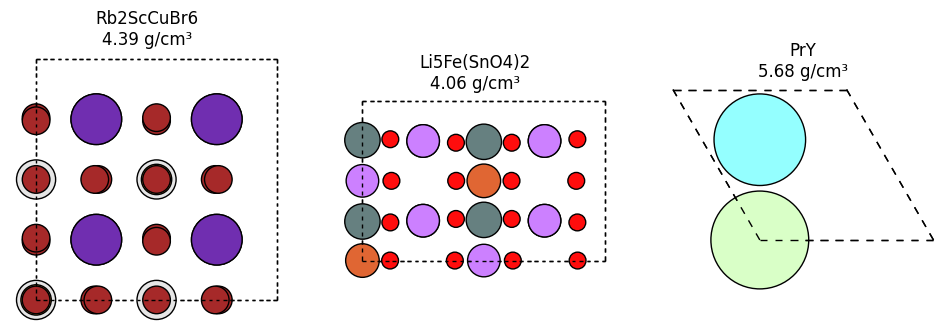

In [14]:
import random
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize.plot import plot_atoms

samples = base_results["Generated CIF"].sample(n=3,random_state=5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, cif in zip(axes, samples):
    structure = Structure.from_str(cif, fmt="cif")
    atoms = AseAtomsAdaptor.get_atoms(structure)

    plot_atoms(atoms, ax, radii=0.5)
    ax.set_title(
        f"{structure.composition.reduced_formula}\n"
        f"{structure.density:.2f} g/cm³"
    )
    ax.axis("off")

plt.show()

#### Density Distribution

We can also take a look at the density distribution

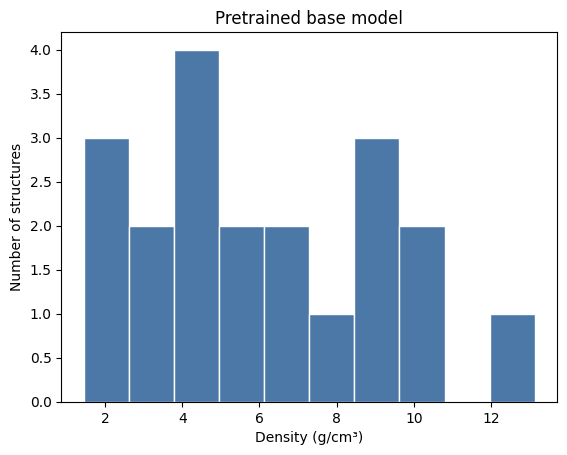

In [15]:
base_densities = []

for cif in base_results["Generated CIF"]:
    structure = Structure.from_str(cif, fmt="cif")
    base_densities.append(structure.density)

plt.hist(base_densities, bins=10, color="#4C78A8", edgecolor="white")
plt.xlabel("Density (g/cm³)")
plt.ylabel("Number of structures")
plt.title("Pretrained base model")
plt.grid(False)
plt.show()

### Try a different prompt

In this example, we used `level_1`, so the model started from a minimal prompt and decided both the composition and crystal structure itself.

CrystaLLM can also start with more information:

- `level_1`: minimal prompt
- `level_2`: composition
- `level_3`: composition and atomic information
- `level_4`: composition, atomic information and space group

Try changing the prompt level and see how giving the model more information affects what it generates.

## Part 2. Compare a toy density model with a pretrained density model

In Part 1, we used an unconditional base model. It was not given a target density, so it was free to generate structures from the distribution it learned during pretraining.

We will now compare **two density-conditioned models**:
1. The toy model produced in the earlier fine-tuning exercise
2. The fully pretrained density-and-stability model

Both models will be asked to generate structures with a target density of **6.0 g/cm³**. and we want to see how a small workshop fine-tune compares with a model trained more extensively for property-conditioned generation.

To keep the comparison consistent:

- both models use a `level_1` prompt;
- both use the same sampling temperature;
- both generate 50 valid CIFs;
- the density of every generated structure is calculated in the same way.

### 1. Define the models and comparison settings

In [29]:
import json
import pandas as pd
from pathlib import Path

TOY_MODEL = f"{HF_USERNAME}/MP-20-Density"
PRETRAINED_DENSITY_MODEL = "c-bone/CrystaLLM-pi_density"

MODEL_REGISTRY = "data/my_custom_models.json"
OUTPUT_DIR = Path("data/workshop_generation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOY_OUTPUT = OUTPUT_DIR / "toy_density_model.parquet"
PRETRAINED_DENSITY_OUTPUT = OUTPUT_DIR / "pretrained_density_model.parquet"

print(f"Toy model: {TOY_MODEL}")
print(f"Pretrained density model: {PRETRAINED_DENSITY_MODEL}")

Toy model: Neutrino155/MP-20-Density
Pretrained density model: c-bone/CrystaLLM-pi_density


### 2. Generate structures with toy model/pretrained density model

**Toy model**

First up is our toy model.

This is the model that was fine-tuned earlier using the small toy dataset of approximately 1,000 crystal structures. It was trained to use density as its generation condition, so we give it one value: 6.0

This tells the model that we would like structures with a target density of 6.0 g/cm³.

The model will not necessarily generate structures with exactly this density every time. That is what we are going to investigate later:) for now, let’s generate 50 valid structures and see what it comes up with.

In [30]:
!python _load_and_generate.py \
    --hf_model_path {TOY_MODEL} \
    --model_registry {MODEL_REGISTRY} \
    --level level_1 \
    --condition_lists "6.0" \
    --num_return_sequences 20 \
    --max_return_attempts 5 \
    --target_valid_cifs 50 \
    --output_parquet {TOY_OUTPUT}

2026-07-29 17:08:53.520004: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

Model Configuration
Path: Neutrino155/MP-20-Density
Type: PKV
Task: Conditioning model trained on toy density dataset

Executing Batch Generation
Tokenizer validation passed: token vocabulary is consistent.
config.json: 100% 951/951 [00:00<00:00, 6.38MB/s]
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
model.safetensors: 100% 108M/108M [00:03<00:00, 30.0MB/s]
Generating CIFs...: 100% 50/50 [00:42<00:00,  1.18it/s]

Converting CIFs to standard CIF format
Processing 50 records using 4 worker(s)
Processing Generated CIF: 100% 50/50 [00:07<00:00,  6.70it/s]
Multi-worker processing completed: 50 record

**Pretrained Density Model**

Next, we will generate another 50 valid structures using the pretrained density model.This model was trained on a much larger dataset than our toy model. The model generates crystal structures based on two target scalar properties:

1. Density (we set it to the valjue of 6.0 g/cm³ in here )
2. Energy above hull (this is a proxy for thermodynamic stability and we set it to 0.0 eV/atom in here)

Although the model needs both values as input, our comparison in this notebook will focus only on the densities of the generated structures.

We will use the same generation settings as before and collect another 50 valid CIFs. Once both sets are ready, we can compare their density distributions and see whether one model stays closer to the target than the other.

In [ ]:
!python _load_and_generate.py \
    --hf_model_path {PRETRAINED_DENSITY_MODEL} \
    --level level_1 \
    --condition_lists "6.0,0.0" \
    --num_return_sequences 20 \
    --max_return_attempts 5 \
    --target_valid_cifs 50 \
    --output_parquet {PRETRAINED_DENSITY_OUTPUT}

### 3. Compare the density distributions

Now we have set of structures from each model. But even though we asked both models for a target density of 6.0 g/cm³, this doesnt mean that every generated structure will have exactly that density.

So lets calculate the actual density of each generated CIF and see what the two models really gave us.

In [ ]:
from pymatgen.core import Structure

toy_results = pd.read_parquet(TOY_OUTPUT)
pretrained_results = pd.read_parquet(PRETRAINED_DENSITY_OUTPUT)

toy_densities = []
for cif in toy_results["Generated CIF"]:
    structure = Structure.from_str(cif, fmt="cif")
    toy_densities.append(structure.density)

pretrained_densities = []
for cif in pretrained_results["Generated CIF"]:
    structure = Structure.from_str(cif, fmt="cif")
    pretrained_densities.append(structure.density)

print(f"Toy model: {len(toy_results)} structures")
print(f"Pretrained density model: {len(pretrained_results)} structures")

Now lets visualise the results.

The x-axis shows density and the y-axis shows how many structures fall into each interval. The dashed line shows the target density of 6.0 g/cm³.

Look at the centre and width of each distribution. With 50 structures, we can also see whether either distribution begins to form a clear peak or a bell curve

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    [toy_densities, pretrained_densities],
    label=["Toy model", "Pretrained density model"],
)

plt.axvline(6.0, color="black", linestyle="--", label="Target density")
plt.xlabel("Density (g/cm³)")
plt.ylabel("Number of structures")
plt.title("Density distribution of generated structures")
plt.legend()
plt.show()

### 4. Look at a few generated structures

The density distribution gives us the overall picture but now lets actually look at a few of the crystals :) We will randomly choose three structures from each model.

In [ ]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize.plot import plot_atoms

toy_examples = toy_results["Generated CIF"].sample(3, random_state=5)
pretrained_examples = pretrained_results["Generated CIF"].sample(3, random_state=5)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, cif in zip(axes[0], toy_examples):
    structure = Structure.from_str(cif, fmt="cif")

    plot_atoms(AseAtomsAdaptor.get_atoms(structure), ax, radii=0.5)
    ax.set_title(f"Toy model\n{structure.composition.reduced_formula}\n{structure.density:.2f} g/cm³")
    ax.axis("off")

for ax, cif in zip(axes[1], pretrained_examples):
    structure = Structure.from_str(cif, fmt="cif")

    plot_atoms(AseAtomsAdaptor.get_atoms(structure), ax, radii=0.5)
    ax.set_title(f"Pretrained model\n{structure.composition.reduced_formula}\n{structure.density:.2f} g/cm³")
    ax.axis("off")

plt.tight_layout()
plt.show()